# Shadow-32 고정 라운드키 — NOP 패딩 / 12,500 샘플 CPA

- 펌웨어 `shadow32_nop` : 풀 사이퍼(16라운드) + NOP 패딩, trigger 가 NOP 까지 포함
  (gcc 10.2.1, `-O0`). 사이퍼는 실측 12042 샘플에서 끝나고 이후 458 샘플이 NOP 구간이다.
- 수집 : clkout 7.5MHz / adc 7.5MHz (1 sample/cycle), **samples = 12500**, 2048 트레이스
- 위상 : **seekclip** — 클리핑이 나올 때까지 위상 리셋(고진폭 위상). 실측상 declipping 대비
  SNR 이 약 6배 높다.
- CPA : R1·R2 는 8-bit(0~127 탐색), R3·R4 는 4-bit + 키스케줄 NX.
  **구간만** 이번 수집의 실측 누설 위치에 맞춰 바꿨다.

| 라운드 | 실측 누설 범위 | 사용 구간 |
|---|---|---|
| R1 | 548 ~ 976 | 1100 |
| R2 | 1296 ~ 1724 | 1850 |
| R3 | 2132 ~ 2632 | 2750 |
| R4 | 2879 ~ 3380 | 3500 |

In [1]:
from tqdm.notebook import trange
import numpy as np
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
FONT = 7
W_FULL = 7.09
H_TRACE = 1.60
H_FULL = 1.95
W_HALF, H_HALF = 3.46, 1.70
DPI = 600
plt.rcParams.update({
    "font.size": FONT, "axes.labelsize": FONT, "axes.titlesize": FONT,
    "xtick.labelsize": FONT - 1, "ytick.labelsize": FONT - 1,
    "legend.fontsize": FONT - 1, "axes.linewidth": 0.5,
    "xtick.major.width": 0.5, "ytick.major.width": 0.5,
    "xtick.major.size": 2.0, "ytick.major.size": 2.0,
    "xtick.major.pad": 1.5, "ytick.major.pad": 1.5,
    "axes.labelpad": 1.5, "grid.linewidth": 0.35,
    "legend.frameon": True, "legend.framealpha": 0.9, "legend.borderaxespad": 0.3,
    "figure.dpi": 120, "figure.constrained_layout.use": True,
    "figure.constrained_layout.h_pad": 0.01, "figure.constrained_layout.w_pad": 0.01,
})

NPZ    = "../data/shadow32_fixedkey/s32_ref_12500.npz"
FIGDIR = "../figures/shadow32_fixedkey"
os.makedirs(FIGDIR, exist_ok=True)

CPA_THRESH = 0.5
W1, W2, W3, W4 = 1100, 1850, 2750, 3500

d = np.load(NPZ)
trace = np.array(d['traces'])
pt    = np.array(d['pt'])
RK_TRUE = [int(x) for x in d['rk'][:16]]

f = trace.astype(np.float64)
print("trace", trace.shape, "| pt", pt.shape)
print("min=%+.3f max=%+.3f  클리핑샘플 %.3f%%  위상=%s"
      % (f.min(), f.max(), (np.abs(f) >= 0.4959).mean()*100, str(d['phase'])))
print("정답 RK1..RK4 =", " ".join("%02X" % x for x in RK_TRUE))

trace (2048, 12500) | pt (2048, 4)
min=-0.223 max=+0.496  클리핑샘플 2.063%  위상=seekclip
정답 RK1..RK4 = 0D 3B 60 33 43 60 25 3C 13 25 89 C5 3C 89 0D 5D


## 수집 파형

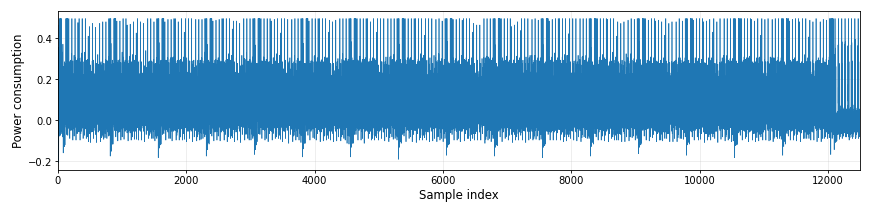

In [2]:
t = np.asarray(trace[0], np.float64)
plt.figure(figsize=(W_FULL, H_TRACE))
plt.plot(t, lw=0.4)
plt.grid(True, alpha=0.35)
plt.xlabel('Sample index'); plt.ylabel('Power consumption'); plt.xlim([0, len(t)])
plt.savefig(FIGDIR + "/trace.png", format='png', dpi=DPI)
plt.show()

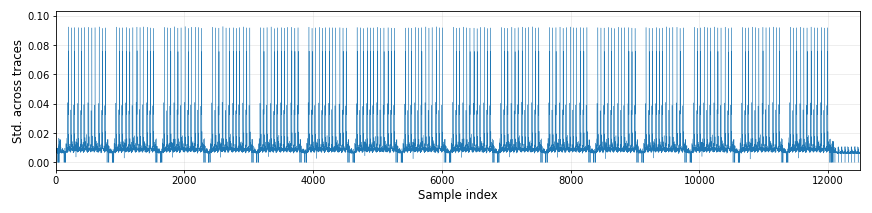

사이퍼 구간(0~12000) 평균 0.01339 | NOP 구간(12042~12500) 평균 0.00706


In [3]:
sd = np.asarray(trace, np.float64).std(axis=0)
plt.figure(figsize=(W_FULL, H_TRACE))
plt.plot(sd, lw=0.2)
plt.grid(True, alpha=0.35)
plt.xlabel('Sample index'); plt.ylabel('Std. across traces'); plt.xlim([0, len(sd)])
plt.savefig(FIGDIR + "/std_cipher_vs_nop.png", format='png', dpi=DPI)
plt.show()
print("사이퍼 구간(0~12000) 평균 %.5f | NOP 구간(12042~12500) 평균 %.5f"
      % (sd[:12000].mean(), sd[12042:].mean()))

## CPA 함수 (원본 그대로)

In [4]:
def bit_rol(val, rot, n_bit):
    return (np.left_shift(val, rot) ^ np.right_shift(val, n_bit-rot)) & (2**n_bit - 1)

def hw(pt):
    hypo = []
    hypo.append([bin(np.int32(p)).count('1') for p in pt])
    return np.array(hypo)

def corr(A, B):
    if len(A) != len(B):
        raise(ValueError, "operands could not be broadcast together")
    def _init(A, B):
        a = np.array(A, dtype=np.float64); b = np.array(B, dtype=np.float64)
        try :    return matlab_like_corr(a, b)
        except:  return np.corrcoef(a, b)[0, 1]
    def matlab_like_corr(A, B):
        np.seterr(divide='ignore', invalid='ignore')
        DA = A - np.mean(A, axis=0); DB = B - np.mean(B, axis=0)
        CV = np.dot(DA.T, DB) / np.double(len(A))
        VA = np.mean(np.square(DA), axis=0)[:, np.newaxis]
        VB = np.mean(np.square(DB), axis=0)[np.newaxis, :]
        return (CV / np.sqrt(np.dot(VA, VB)))
    ret = _init(A, B); ret[np.isnan(ret)] = 0
    return ret

def cpa_on_target(gk_st, gk_end, power_trace, hypo_value):
    ret_cpa = []
    for i in trange(gk_st, gk_end+1):
        hypo_hw = hw(hypo_value ^ i)
        ret_corr = corr(power_trace, hypo_hw.T)
        ret_cpa.append(ret_corr.reshape([-1]))
    return np.array(ret_cpa).T

In [5]:
def cpa_result_show(ret_cpa, ind_start=0, filename='', figsize=(W_HALF, H_HALF)):
    plt.figure(figsize=figsize)
    mpl.rcParams['text.usetex'] = False
    maxi = np.max(ret_cpa); mini = np.min(ret_cpa)
    for i in range(128):
        if np.any(ret_cpa[:, i]==maxi):
            print("guess_k0_max: ", hex(i+ind_start)); maxi_idx = i
        if np.any(ret_cpa[:, i]==mini):
            print("guess_k1_min: ", hex(i+ind_start)); mini_idx = i
        else:
            plt.plot((ret_cpa[:, i]), color=[0.88,0.88,0.88], lw=0.25, rasterized=True)
    key_label = "0x" + ("%02X" % (maxi_idx+ind_start))
    plt.plot((ret_cpa[:, maxi_idx]), color='#d62728', lw=0.8, label=key_label)
    key_label = "0x" + ("%02X" % (mini_idx+ind_start))
    plt.plot((ret_cpa[:, mini_idx]), color='#2ca02c', lw=0.8, label=key_label)
    plt.ylim([-0.95, 0.95]); plt.grid(True, alpha=0.35); plt.legend(handlelength=1.1, borderpad=0.2, handletextpad=0.3, labelspacing=0.2)
    plt.xlabel('Sample index'); plt.ylabel('Correlation coefficient')
    plt.savefig(FIGDIR + "/" + filename + ".png", format='png', dpi=DPI)
    plt.show()
    return maxi_idx+ind_start, mini_idx+ind_start

def abs_cpa_result_show(ret_corr, ind_start=0, filename='', figsize=(W_HALF, H_HALF)):
    plt.figure(figsize=figsize)
    ret_cpa = np.abs(ret_corr)
    maxi = np.max(ret_cpa)
    mpl.rcParams['text.usetex'] = False
    for i in range(128):
        if np.any(ret_cpa[:, i]==maxi) and (maxi > CPA_THRESH):
            print("guess_max: ", hex(i+ind_start)); maxi_idx = i
        else:
            plt.plot((ret_cpa[:, i]), color=[0.88,0.88,0.88], lw=0.25, rasterized=True)
    if maxi > CPA_THRESH:
        plt.plot((ret_cpa[:, maxi_idx]), color='#d62728',
                 label="0x" + ("%02X" % (maxi_idx+ind_start)))
    plt.ylim([-0.05, 0.95]); plt.grid(True, alpha=0.35)
    plt.xlabel('Sample index'); plt.ylabel('Absolute correlation')
    if maxi > CPA_THRESH: plt.legend(handlelength=1.1, borderpad=0.2, handletextpad=0.3, labelspacing=0.2)
    plt.savefig(FIGDIR + "/" + filename + ".png", format='png', dpi=DPI)
    plt.show()
    return (maxi_idx+ind_start) if maxi > CPA_THRESH else None

def nx8(x):
    k=[(x>>(7-i))&1 for i in range(8)]
    nb=[k[0]&(k[0]^k[6]), k[1]&(k[1]^k[7]), k[2]&(k[2]^k[0]^k[6]), k[3]&(k[3]^k[1]^k[7]),
        k[4]&(k[4]^k[2]^k[0]^k[6]), k[5]&(k[5]^k[3]^k[1]^k[7]), k[6]&(k[4]^k[2]^k[0]), k[7]&(k[5]^k[3]^k[1])]
    return sum(nb[i]<<(7-i) for i in range(8))

def F(x): return (bit_rol(x,1,8)&bit_rol(x,7,8))^bit_rol(x,2,8)

def cpa_4bit_show(power, hypo, upper, filename):
    ret = cpa_on_target(0, 15, power, hypo ^ (upper<<4))
    lo  = int(np.argmax(np.max(np.abs(ret), axis=0)))
    plt.figure(figsize=(W_HALF, H_HALF))
    for i in range(16):
        if i!=lo: plt.plot(np.abs(ret[:, i]), color=[0.88,0.88,0.88], lw=0.25, rasterized=True)
    plt.plot(np.abs(ret[:, lo]), color='#d62728', lw=0.8, label='0x%02X'%((upper<<4)|lo))
    plt.ylim([-0.05,0.95]); plt.grid(True, alpha=0.35); plt.legend(handlelength=1.1, borderpad=0.2, handletextpad=0.3, labelspacing=0.2)
    plt.xlabel('Sample index'); plt.ylabel('Absolute correlation')
    plt.savefig(FIGDIR + "/" + filename + ".png", format='png', dpi=DPI)
    plt.show()
    return (upper<<4)|lo

## Round 1

guess_k0_max:  0xd
guess_k1_min:  0x72


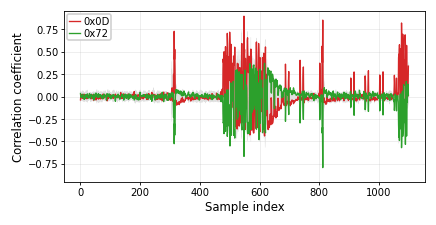

In [6]:
hypo_vl = (bit_rol(pt[:, 0], 1, 8) & bit_rol(pt[:, 0], 7, 8)) ^  pt[:, 1] ^ bit_rol(pt[:, 0], 2, 8)
ret_cpa = cpa_on_target(0, 127, trace[:, :W1], hypo_vl)
guess_k0, _ = cpa_result_show(ret_cpa, 0, "cpa-k0-128", figsize=(W_HALF, H_HALF))

guess_k0_max:  0x8d
guess_k1_min:  0xf2


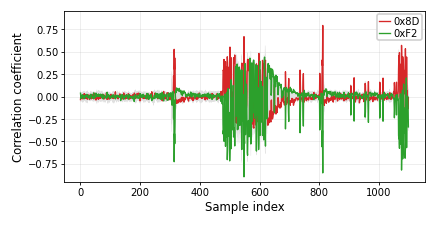

In [7]:
hypo_vl = (bit_rol(pt[:, 0], 1, 8) & bit_rol(pt[:, 0], 7, 8)) ^  pt[:, 1] ^ bit_rol(pt[:, 0], 2, 8)
ret_cpa = cpa_on_target(128, 255, trace[:, :W1], hypo_vl)
_, guess_k0_bar = cpa_result_show(ret_cpa, 128, "cpa-k0-256", figsize=(W_HALF, H_HALF))

guess_max:  0x3b


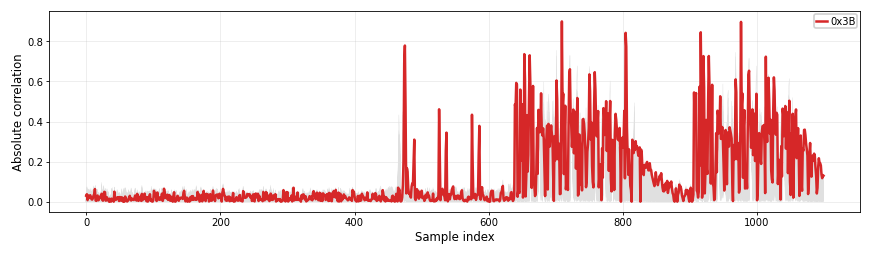

In [8]:
hypo_vl = (bit_rol(pt[:, 2], 1, 8) & bit_rol(pt[:, 2], 7, 8)) ^  pt[:, 3] ^ bit_rol(pt[:, 2], 2, 8)
ret_cpa = cpa_on_target(0, 127, trace[:, :W1], hypo_vl)
guess_k1 = abs_cpa_result_show(ret_cpa, 0, "cpa-k1", figsize=(W_FULL, H_FULL))
guess_k1_bar = guess_k1 ^ 0xff

guess_max:  0x60


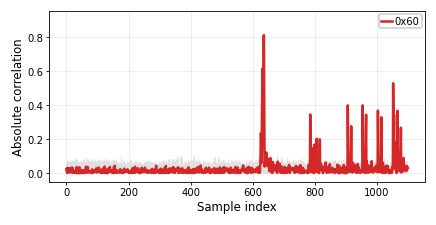

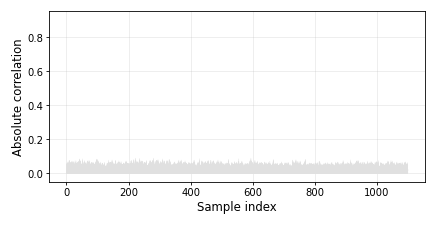

guess_k2 = 0x60 | peak |r| = 0.811


In [9]:
state_0 = (bit_rol(pt[:, 0], 1, 8) & bit_rol(pt[:, 0], 7, 8)) ^  pt[:, 1] ^ bit_rol(pt[:, 0], 2, 8) ^ guess_k0;
hypo_vl = (bit_rol(state_0, 1, 8) & bit_rol(state_0, 7, 8)) ^  pt[:, 0] ^ bit_rol(state_0, 2, 8)
ret_cpa1 = cpa_on_target(0, 127, trace[:, :W1], hypo_vl)

state_0_bar = state_0 ^ 0xff;
hypo_vl = (bit_rol(state_0_bar, 1, 8) & bit_rol(state_0_bar, 7, 8)) ^  pt[:, 0] ^ bit_rol(state_0_bar, 2, 8)
ret_cpa2 = cpa_on_target(0, 127, trace[:, :W1], hypo_vl)

abs_cpa_result_show(ret_cpa1, 0, "cpa-k2-normal", figsize=(W_HALF, H_HALF))
abs_cpa_result_show(ret_cpa2, 0, "cpa-k2-bar",    figsize=(W_HALF, H_HALF))

guess_k2 = int(np.argmax(np.max(np.abs(ret_cpa1), axis=0)))
guess_k2_bar = guess_k2 ^ 0xff
print('guess_k2 =', hex(guess_k2), '| peak |r| = %.3f' % np.abs(ret_cpa1).max())

guess_max:  0x33


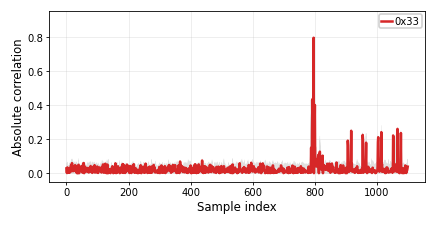

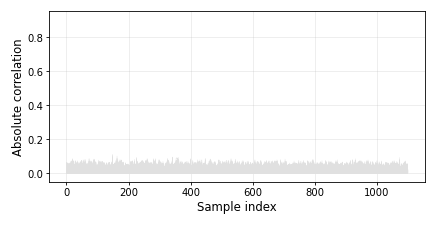

guess_k3 = 0x33 | peak |r| = 0.795


In [10]:
state_1 = (bit_rol(pt[:, 2], 1, 8) & bit_rol(pt[:, 2], 7, 8)) ^  pt[:, 3] ^ bit_rol(pt[:, 2], 2, 8) ^ guess_k1;
hypo_vl = (bit_rol(state_1, 1, 8) & bit_rol(state_1, 7, 8)) ^  pt[:, 2] ^ bit_rol(state_1, 2, 8)
ret_cpa1 = cpa_on_target(0, 127, trace[:, :W1], hypo_vl)

state_1_bar = (bit_rol(pt[:, 2], 1, 8) & bit_rol(pt[:, 2], 7, 8)) ^  pt[:, 3] ^ bit_rol(pt[:, 2], 2, 8) ^ guess_k1_bar;
hypo_vl = (bit_rol(state_1_bar, 1, 8) & bit_rol(state_1_bar, 7, 8)) ^  pt[:, 2] ^ bit_rol(state_1_bar, 2, 8)
ret_cpa2 = cpa_on_target(0, 127, trace[:, :W1], hypo_vl)

abs_cpa_result_show(ret_cpa1, 0, "cpa-k3-normal", figsize=(W_HALF, H_HALF))
abs_cpa_result_show(ret_cpa2, 0, "cpa-k3-bar",    figsize=(W_HALF, H_HALF))

guess_k3 = int(np.argmax(np.max(np.abs(ret_cpa1), axis=0)))
guess_k3_bar = guess_k3 ^ 0xff
print('guess_k3 =', hex(guess_k3), '| peak |r| = %.3f' % np.abs(ret_cpa1).max())

In [11]:
got1 = [guess_k0, guess_k1, guess_k2, guess_k3]
print("RK1 복구 =", " ".join("%02X" % x for x in got1))
print("RK1 정답 =", " ".join("%02X" % x for x in RK_TRUE[:4]))
print("=> 일치 %d/4" % sum(a==b for a,b in zip(got1, RK_TRUE[:4])))

RK1 복구 = 0D 3B 60 33
RK1 정답 = 0D 3B 60 33
=> 일치 4/4


## Round 2

In [12]:
state_0 = (bit_rol(pt[:, 0], 1, 8) & bit_rol(pt[:, 0], 7, 8)) ^  pt[:, 1] ^ bit_rol(pt[:, 0], 2, 8) ^ guess_k0;
state_1 = (bit_rol(pt[:, 2], 1, 8) & bit_rol(pt[:, 2], 7, 8)) ^  pt[:, 3] ^ bit_rol(pt[:, 2], 2, 8) ^ guess_k1;
state_2 = (bit_rol(state_0 , 1, 8) & bit_rol(state_0 , 7, 8)) ^  pt[:, 0] ^ bit_rol(state_0 , 2, 8) ^ guess_k2;
state_3 = (bit_rol(state_1 , 1, 8) & bit_rol(state_1 , 7, 8)) ^  pt[:, 2] ^ bit_rol(state_1 , 2, 8) ^ guess_k3;
sd_l0, sd_l1, sd_r0, sd_r1 = state_1, state_2, state_0, state_3

guess_max:  0x43


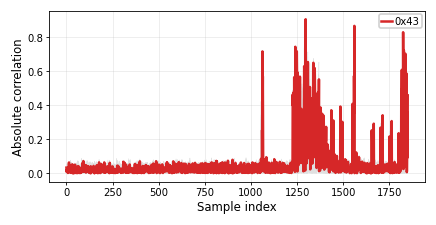

In [13]:
hypo_vl = (bit_rol(sd_l0, 1, 8) & bit_rol(sd_l0, 7, 8)) ^  sd_l1 ^ bit_rol(sd_l0, 2, 8)
ret_cpa = cpa_on_target(0, 127, trace[:, :W2], hypo_vl)
guess_r2k0 = abs_cpa_result_show(ret_cpa, 0, "cpa-r2-k0", figsize=(W_HALF, H_HALF))
guess_r2k0_bar = guess_r2k0 ^ 0xff

guess_max:  0x60


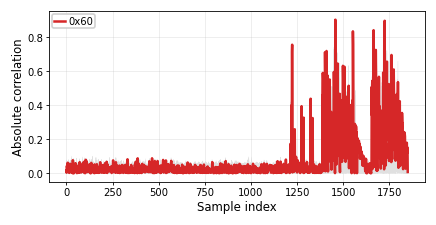

In [14]:
hypo_vl = (bit_rol(sd_r0, 1, 8) & bit_rol(sd_r0, 7, 8)) ^  sd_r1 ^ bit_rol(sd_r0, 2, 8)
ret_cpa = cpa_on_target(0, 127, trace[:, :W2], hypo_vl)
guess_r2k1 = abs_cpa_result_show(ret_cpa, 0, "cpa-r2-k1", figsize=(W_HALF, H_HALF))
guess_r2k1_bar = guess_r2k1 ^ 0xff

guess_max:  0x25


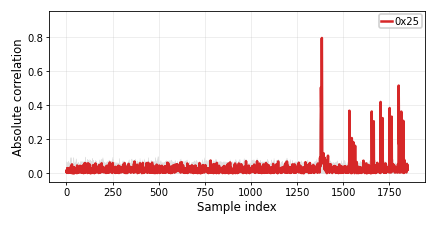

In [15]:
r2state_0 = (bit_rol(sd_l0, 1, 8) & bit_rol(sd_l0, 7, 8)) ^  sd_l1 ^ bit_rol(sd_l0, 2, 8) ^ guess_r2k0;
hypo_vl = (bit_rol(r2state_0, 1, 8) & bit_rol(r2state_0, 7, 8)) ^ sd_l0 ^ bit_rol(r2state_0, 2, 8)
ret_cpa = cpa_on_target(0, 127, trace[:, :W2], hypo_vl)
guess_r2k2 = abs_cpa_result_show(ret_cpa, 0, "cpa-r2-k2", figsize=(W_HALF, H_HALF))
guess_r2k2_bar = guess_r2k2 ^ 0xff

guess_max:  0x3c


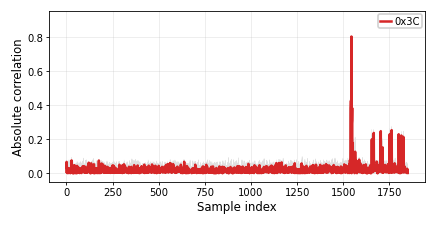

RK2 복구 = 43 60 25 3C
RK2 정답 = 43 60 25 3C
=> 일치 4/4


In [16]:
r2state_1 = (bit_rol(sd_r0, 1, 8) & bit_rol(sd_r0, 7, 8)) ^  sd_r1 ^ bit_rol(sd_r0, 2, 8) ^ guess_r2k1;
hypo_vl = (bit_rol(r2state_1, 1, 8) & bit_rol(r2state_1, 7, 8)) ^ sd_r0 ^ bit_rol(r2state_1, 2, 8)
ret_cpa = cpa_on_target(0, 127, trace[:, :W2], hypo_vl)
guess_r2k3 = abs_cpa_result_show(ret_cpa, 0, "cpa-r2-k3", figsize=(W_HALF, H_HALF))
guess_r2k3_bar = guess_r2k3 ^ 0xff

got2 = [guess_r2k0, guess_r2k1, guess_r2k2, guess_r2k3]
print("RK2 복구 =", " ".join("%02X" % x for x in got2))
print("RK2 정답 =", " ".join("%02X" % x for x in RK_TRUE[4:8]))
print("=> 일치 %d/4" % sum(a==b for a,b in zip(got2, RK_TRUE[4:8])))

## Round 3

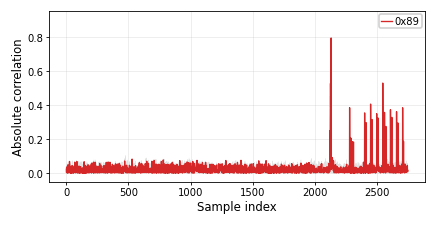

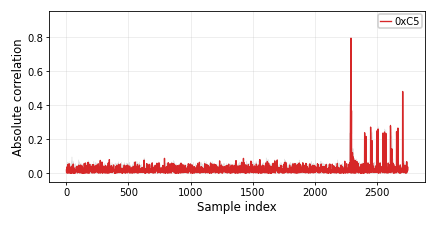

RK3 복구 = 13 25 89 C5
RK3 정답 = 13 25 89 C5
=> 일치 4/4


In [17]:
r2_s0=F(sd_l0)^sd_l1^guess_r2k0; r2_s1=F(sd_r0)^sd_r1^guess_r2k1
r2_l1=F(r2_s0)^sd_l0^guess_r2k2;  r2_r1=F(r2_s1)^sd_r0^guess_r2k3
td_l0,td_l1,td_r0,td_r1 = r2_s1, r2_l1, r2_s0, r2_r1

nxo3 = nx8(((guess_k0&0xF)<<4)|(guess_k1&0xF))
RK3_0 = ((nxo3>>4)&0xF)<<4 | ((guess_r2k3>>4)&0xF)
RK3_1 = guess_r2k2
r3_s0 = F(td_l0)^td_l1^RK3_0; r3_s1 = F(td_r0)^td_r1^RK3_1

RK3_2 = cpa_4bit_show(trace[:, :W3], F(r3_s0)^td_l0, nxo3&0xF,       "cpa-r3-k2")
RK3_3 = cpa_4bit_show(trace[:, :W3], F(r3_s1)^td_r0, guess_r2k3&0xF, "cpa-r3-k3")
got3 = [RK3_0,RK3_1,RK3_2,RK3_3]
print("RK3 복구 =", " ".join("%02X" % x for x in got3))
print("RK3 정답 =", " ".join("%02X" % x for x in RK_TRUE[8:12]))
print("=> 일치 %d/4" % sum(a==b for a,b in zip(got3, RK_TRUE[8:12])))

## Round 4

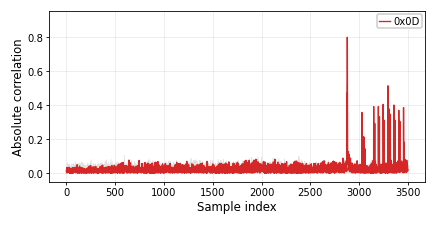

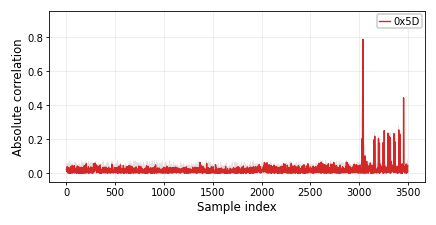

RK4 복구 = 3C 89 0D 5D
RK4 정답 = 3C 89 0D 5D

RK1..RK4 복구 = 0D 3B 60 33 43 60 25 3C 13 25 89 C5 3C 89 0D 5D
RK1..RK4 정답 = 0D 3B 60 33 43 60 25 3C 13 25 89 C5 3C 89 0D 5D
=> 최종 일치 16/16


In [18]:
r3_l1=F(r3_s0)^td_l0^RK3_2; r3_r1=F(r3_s1)^td_r0^RK3_3
qd_l0,qd_l1,qd_r0,qd_r1 = r3_s1, r3_l1, r3_s0, r3_r1

nxo4 = nx8(((guess_r2k0&0xF)<<4)|(guess_r2k1&0xF))
RK4_0 = ((nxo4>>4)&0xF)<<4 | ((RK3_3>>4)&0xF)
RK4_1 = RK3_2
r4_s0 = F(qd_l0)^qd_l1^RK4_0; r4_s1 = F(qd_r0)^qd_r1^RK4_1

RK4_2 = cpa_4bit_show(trace[:, :W4], F(r4_s0)^qd_l0, nxo4&0xF,  "cpa-r4-k2")
RK4_3 = cpa_4bit_show(trace[:, :W4], F(r4_s1)^qd_r0, RK3_3&0xF, "cpa-r4-k3")
got4 = [RK4_0,RK4_1,RK4_2,RK4_3]
print("RK4 복구 =", " ".join("%02X" % x for x in got4))
print("RK4 정답 =", " ".join("%02X" % x for x in RK_TRUE[12:16]))

rec = got1 + got2 + got3 + got4
n = sum(a==b for a,b in zip(rec, RK_TRUE))
print()
print("RK1..RK4 복구 =", " ".join("%02X" % x for x in rec))
print("RK1..RK4 정답 =", " ".join("%02X" % x for x in RK_TRUE))
print("=> 최종 일치 %d/16" % n)